# 10 - Sampling, and what lies beyond

This final notebook covers two things.

1. **Sampling.** The trained model gives a probability for every possible next token. *How* you pick from those probabilities (greedy, temperature, top-k, or top-p, all explained below) changes the character of the output considerably, and we will see each in turn.
2. **What lies beyond.** An honest map of what separates your roughly one-million-number Shakespeare model from a frontier model, meaning one of the large commercial systems. The short version is that the difference is mostly scale, data, and alignment rather than new mysteries; you have already built every core idea.

In [ ]:
# Colab setup -- fetch the files this notebook needs.
# (Does nothing when run locally in the course folder.)
import os, urllib.request
BASE = ("https://raw.githubusercontent.com/waze"
        "emlabs/llm-book-code/main/")
for f in ['gpt.py']:
    if not os.path.exists(f):
        d = os.path.dirname(f)
        if d: os.makedirs(d, exist_ok=True)
        urllib.request.urlretrieve(BASE + f, f)
        print("downloaded", f)
if not os.path.exists("checkpoints/gpt_shakespeare.pt"):
    print("NOTE: this notebook loads the model trained in\n"
          "notebook 09. Run notebook 09 first (in the same\n"
          "Colab session), then re-run this cell.")


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>import os, urllib.request</code>: two standard-library toolboxes: checking files on disk, and downloading from the web.</li>
<li><code>BASE = (...)</code>: the web address of this course's folder on GitHub, split over two lines (Python glues adjacent strings together).</li>
<li><code>for f in [...]</code>: loop over the file names this notebook needs.</li>
<li><code>if not os.path.exists(f)</code>: only download what is missing -- running locally, everything already exists, so nothing happens.</li>
<li><code>os.makedirs(d, exist_ok=True)</code>: create the folder for the file if it has one (<code>exist_ok</code> means don't complain if it's already there).</li>
<li><code>urllib.request.urlretrieve(...)</code>: download the file and save it under the same name here.</li>
</ul>
</details>

In [1]:
import torch
from torch.nn import functional as F
from gpt import GPT, GPTConfig
device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")

# load the model we trained in notebook 09
ckpt = torch.load("checkpoints/gpt_shakespeare.pt", map_location=device, weights_only=False)
cfg = ckpt["config"]
model = GPT(cfg).to(device); model.load_state_dict(ckpt["model"]); model.eval()
stoi, itos = ckpt["stoi"], ckpt["itos"]
decode = lambda l: "".join(itos[i] for i in l)
print(f"loaded trained GPT ({model.num_params():,} params) on {device}")

loaded trained GPT (824,897 params) on mps


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>ckpt = torch.load(..., map_location=device, weights_only=False)</code>: read the checkpoint file back. <code>map_location</code> says where the tensors should live; the flag allows the bundled config object to load too.</li>
<li><code>cfg = ckpt["config"]</code>: pull out the pieces we saved in notebook 09 (config, weights, tokenizer tables).</li>
<li><code>model = GPT(cfg).to(device); model.load_state_dict(ckpt["model"])</code>: build a fresh model skeleton and pour the saved weights into it.</li>
<li><code>model.eval()</code>: inference mode (dropout off).</li>
<li><code>decode = lambda l: "".join(itos[i] for i in l)</code>: rebuild the decoder from the saved table.</li>
</ul>
</details>

## How sampling works

At each step the model hands you a **probability distribution** over the whole vocabulary, for example "next character: 31% `t`, 12% `h`, and so on." Sampling is simply how you pick one character from that list, and the rule you choose changes the whole personality of the output:

- **Greedy**: always take the single most likely token (using `argmax`, which just means "the position of the largest value"). It is completely predictable, but it gets stuck in loops and reads as dull; you will see it repeat "the world of the world" below.
- **Temperature**: a creativity dial. You divide the logits by a number `T` before applying softmax. A `T` below 1 widens the gaps so the top choices dominate (safer, more repetitive); a `T` above 1 narrows the gaps so long-shot choices get a look in (more varied, more typos); and `T` equal to 1 leaves the distribution untouched.
- **Top-k**: before sampling, discard everything except the `k` most likely tokens, so the model cannot pick something bizarre from the long tail of unlikely options.
- **Top-p** (also called nucleus sampling): the same idea but adaptive. Keep just enough of the top tokens for their probabilities to add up to `p` (say 0.9), however many that turns out to be.

Below is a single generate function that supports all of them.

In [2]:
@torch.no_grad()
def generate(model, prompt="", max_new_tokens=300, temperature=1.0, top_k=None, top_p=None, greedy=False, seed=0):
    torch.manual_seed(seed)
    idx = torch.tensor([[stoi[c] for c in prompt]] if prompt else [[0]], dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        logits, _ = model(idx[:, -cfg.block_size:])
        logits = logits[:, -1, :]
        if greedy:
            idx_next = logits.argmax(dim=-1, keepdim=True)
        else:
            logits = logits / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float("inf")
            if top_p is not None:
                s_logits, s_idx = torch.sort(logits, descending=True)
                probs = F.softmax(s_logits, dim=-1)
                cum = torch.cumsum(probs, dim=-1)
                remove = cum - probs > top_p                 # keep until cumulative prob passes p
                s_logits[remove] = -float("inf")
                logits = torch.full_like(logits, -float("inf")).scatter(1, s_idx, s_logits)
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, idx_next], dim=1)
    return decode(idx[0].tolist())

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>def generate(model, prompt="", ..., greedy=False, seed=0):</code>: one function with every sampling strategy as an optional setting.</li>
<li><code>torch.manual_seed(seed)</code>: same seed &rarr; same dice rolls &rarr; comparable outputs across strategies.</li>
<li><code>idx = torch.tensor([[stoi[c] for c in prompt]] ...)</code>: encode the prompt to ids (note the double brackets: a batch of one sequence); with no prompt, start from token 0.</li>
<li><code>logits, _ = model(idx[:, -cfg.block_size:])</code>: keep only the last 128 tokens of context (the model can't see further back) and predict.</li>
<li><code>logits = logits[:, -1, :]</code>: take the predictions at the <i>last</i> position only -- that's where the next token gets decided.</li>
<li><code>idx_next = logits.argmax(dim=-1, keepdim=True)</code>: greedy: just take the single highest scorer, no dice.</li>
<li><code>logits = logits / temperature</code>: the creativity dial: dividing by T &lt; 1 stretches the score gaps (sharper, safer), T &gt; 1 squashes them (flatter, wilder).</li>
<li>Top-k block: <code>torch.topk</code> finds the k highest scores; <code>logits[logits &lt; v[:, [-1]]] = -inf</code> erases everything below the k-th (and -inf becomes probability 0 after softmax).</li>
<li>Top-p block: <code>torch.sort</code> descending, <code>torch.cumsum</code> builds the running total of probability, <code>cum - probs &gt; top_p</code> marks tokens past the cutoff -- "keep just enough of the top tokens to cover 90%." <code>scatter</code> writes the kept scores back to their original positions.</li>
<li><code>probs = F.softmax(logits, dim=-1); idx_next = torch.multinomial(probs, num_samples=1)</code>: turn scores into probabilities and roll the weighted die; <code>torch.cat</code> appends the pick and the loop continues.</li>
</ul>
</details>

### Greedy versus temperature

Greedy is predictable and quickly repetitive. A low temperature is safe but a little dull; a high temperature is creative but error-prone. Watch how the texture of the text changes.

In [3]:
print("=== GREEDY (argmax) -- note the repetition ===")
print(generate(model, prompt="ROMEO:", max_new_tokens=200, greedy=True))

=== GREEDY (argmax) -- note the repetition ===


ROMEO:
The world the seat of the world of the world,
And the seal of the world of the world the world,
And the seat of the world of the world,
And the world of the world of the world,
And the world of the w


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>generate(model, prompt="ROMEO:", max_new_tokens=200, greedy=True)</code>: always take the top choice. Watch it fall into a loop ("the world of the world...") -- pure determinism finds a rut and stays there.</li>
</ul>
</details>

In [4]:
for T in [0.5, 1.0, 1.5]:
    print(f"=== temperature = {T} ===")
    print(generate(model, prompt="ROMEO:", max_new_tokens=180, temperature=T, seed=1))
    print()

=== temperature = 0.5 ===


ROMEO:
We shall can the be stealter, and the world to sure,
But thou would he in the world confinitence
Of the moon of the mother wind the doing of this
To be some of her life.

PAULINA:

=== temperature = 1.0 ===


ROMEO:
Wwas their common twices the next of hollowing.

KING LEDWARD IV:
Capuliten, my wife, let them: our mind,
I  well apatient in my teteritanges,
And more sight'd and let him wherefo

=== temperature = 1.5 ===


ROMEO:
Bwas their coundry wit.

MOPSA.

3BELLADY:
No gentleep, Lucious dejaUTIO:
This many confircy ambounted Rome; well,
Fathermenn, we at till you, wruth alas;
If'd alf the pleasces.





<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>for T in [0.5, 1.0, 1.5]:</code>: same prompt, same seed, three temperatures, so the <i>only</i> difference you see is the dial.</li>
<li><code>generate(..., temperature=T, seed=1)</code>: low T is safe and a touch repetitive; T=1 is the raw distribution; high T picks long-shot characters and the spelling falls apart.</li>
</ul>
</details>

### The real distribution behind the temperature knob

You just watched temperature change the generated text. Here is what it is actually reshaping: the trained model's own probability for the next character after a prompt. Low temperature sharpens the bet onto the top few characters; high temperature flattens it toward an even guess. This is the real version of the synthetic slider at the top of the page.

after 'To be, or not to ' the model's top next characters (T=1.0):
    't'  0.162
    'm'  0.113
    'h'  0.094
    's'  0.080
    'b'  0.075
    'y'  0.070
    'a'  0.045
    'p'  0.037
    'd'  0.034
    'c'  0.031


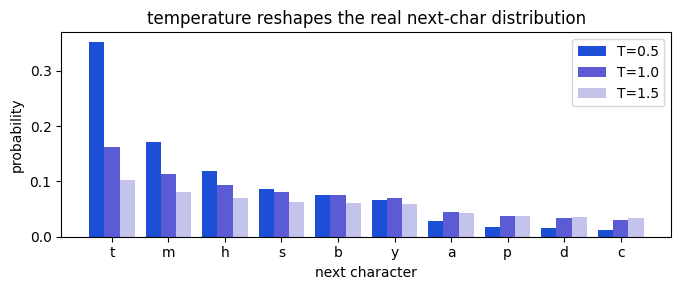

In [5]:
import matplotlib.pyplot as plt

# The model's actual next-char probabilities after a prompt, at three temperatures.
prompt = "To be, or not to "
idx = torch.tensor([[stoi[c] for c in prompt]], device=device)
with torch.no_grad():
    logits, _ = model(idx[:, -cfg.block_size:])
logits = logits[0, -1]                               # one score per possible next char

topp, topi = F.softmax(logits, dim=-1).topk(10)      # the 10 likeliest, at T=1.0
labels = ["\\n" if itos[i.item()] == "\n" else itos[i.item()] for i in topi]
print(f"after {prompt!r} the model's top next characters (T=1.0):")
for c, p in zip(labels, topp):
    print(f"   {c!r:>4}  {p.item():.3f}")

fig, ax = plt.subplots(figsize=(7, 3)); width = 0.27
for k, (T, color) in enumerate(zip([0.5, 1.0, 1.5], ["#1c4fd6", "#5b5bd6", "#c3c3ec"])):
    pr = F.softmax(logits / T, dim=-1)[topi]
    ax.bar([j + k * width for j in range(10)], pr.tolist(), width, label=f"T={T}", color=color)
ax.set_xticks([j + width for j in range(10)]); ax.set_xticklabels(labels)
ax.set_xlabel("next character"); ax.set_ylabel("probability"); ax.legend()
ax.set_title("temperature reshapes the real next-char distribution")
plt.tight_layout(); plt.show()

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>logits, _ = model(idx[:, -cfg.block_size:])</code>: run the trained model on the prompt; <code>logits[0, -1]</code> is its score for every possible next character.</li>
<li><code>F.softmax(...).topk(10)</code>: the ten most likely next characters at temperature 1.0, printed with their probabilities.</li>
<li>The loop over <code>T = 0.5, 1.0, 1.5</code> divides the logits by T before softmax, then plots each resulting distribution side by side.</li>
<li>At <code>T = 0.5</code> the leading character shoots up past 0.35 (a sharp, safe bet); at <code>T = 1.5</code> it drops and the long tail rises (a flatter, riskier guess).</li>
<li>Sampling then just draws one character from whichever curve you picked -- this is the real distribution the slider at the top of the page stood in for.</li>
</ul>
</details>

### Top-k and top-p

Both methods trim away the unlikely tail, so the model makes fewer bizarre character choices, while still sampling rather than always taking the top option (so the output is less repetitive than greedy). These are what real chat models use in practice.

In [6]:
print("=== top-k = 10 ===")
print(generate(model, prompt="KING:", max_new_tokens=180, top_k=10, seed=2))
print("\n=== top-p = 0.9 (nucleus) ===")
print(generate(model, prompt="KING:", max_new_tokens=180, top_p=0.9, seed=2))

=== top-k = 10 ===


KING:
On last, thy short and to the wake, hastings for the world,
Yet what in my happy safety! how not intence
To his fell against affect him; to your great are
All: this times holy and

=== top-p = 0.9 (nucleus) ===


KING:
On last, thou hast and to the water of the mark,
When the pleasure high men a guilty hast
Hence must not loved leave against to as he
me to requeen the arborn. A word, fair love i


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>generate(..., top_k=10, ...)</code>: sample only among the 10 most likely next characters: the wild tail is gone, but variety remains.</li>
<li><code>generate(..., top_p=0.9, ...)</code>: the adaptive version: keep the smallest set of characters whose probabilities add up to 90% -- sometimes 3 candidates, sometimes 20, depending on how confident the model is.</li>
</ul>
</details>

## Beyond: from this to a frontier model

Your model is a real GPT. A frontier model differs in degree and engineering, not in the fundamental ideas. Here is an honest map of the gap.

### 1. Tokenization: subwords, not characters
Real models use **BPE** (notebook 02): a vocabulary of roughly 50,000 to 200,000 subword tokens instead of 65 characters, so sequences are far shorter and each token carries more meaning.

In [7]:
import tiktoken
enc = tiktoken.get_encoding("cl100k_base")    # the tokenizer family used by GPT-3.5/4
s = "The quick brown fox jumps over the lazy dog."
print("our char tokens :", len(s))
print("BPE tokens      :", len(enc.encode(s)), "->", [enc.decode([t]) for t in enc.encode(s)])

our char tokens : 44
BPE tokens      : 10 -> ['The', ' quick', ' brown', ' fox', ' jumps', ' over', ' the', ' lazy', ' dog', '.']


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>enc = tiktoken.get_encoding("cl100k_base")</code>: the tokenizer family GPT-3.5/4 actually use (~100k subword vocabulary).</li>
<li><code>len(s)</code> vs <code>len(enc.encode(s))</code>: the same sentence is 44 characters but only 10 subword tokens: why real models see "words," not letters.</li>
<li><code>[enc.decode([t]) for t in enc.encode(s)]</code>: decode each token id on its own to reveal the chunk it stands for.</li>
</ul>
</details>

### 2. Scale (the big one)
The same design, turned up enormously. Roughly:

| | this notebook | GPT-2 | GPT-3 | frontier (2025-26) |
|---|---|---|---|---|
| parameters | ~0.8 M | 1.5 B | 175 B | ~10^12+ |
| training tokens | ~10^6 | ~10^10 | 3x10^11 | ~10^13+ |
| context | 128 | 1024 | 2048 | 10^5-10^6 |

**Scaling laws** are the finding that the loss falls in a predictable way as you increase the model size, the amount of training data, and the computing power together. (One well-known result, named Chinchilla after the study that found it, is that for a given amount of computing power there is a best balance between model size and data, roughly 20 tokens of training text for every number in the model.) There is no new trick here; there is simply more of everything.

### 3. Inference speed: the KV-cache
Generating text in the naive way re-runs attention over the whole context for every new token, so the work grows with the square of the length (this is what "order T-squared" means: double the length and the work roughly quadruples). Since the keys and values of past tokens do not change, real systems **cache** them and compute only the new token's, which brings the work back down to roughly proportional to the length. This is the single most important speed-up when running a model. (Our `generate` recomputes everything each time, for clarity.)

### 4. Modern architecture tweaks
The 2017 Transformer you built, brought up to date in the style of models like Llama and GPT. Each of these is an optional refinement; the names are given mainly so you can look them up later.
- **RoPE** (rotary position embeddings) replaces the learned table of positions with one based on relative distance, which copes better with longer text.
- **RMSNorm** replaces LayerNorm with a simpler, cheaper version that has the same steadying effect.
- **SwiGLU** replaces the plain feed-forward network with a slightly more capable "gated" version.
- **Grouped-query attention** lets several heads share their keys and values, which makes running the model much cheaper.
- **Flash-Attention** computes exactly the same attention without ever building the full table of scores in memory, saving both memory and time.

### 5. Alignment: from text-predictor to assistant
Your model has done only the first of three stages.
1. **Pretraining**: predict the next token on a huge body of text (what you did). The result is a *base model* that continues text but does not reliably follow instructions.
2. **Supervised fine-tuning** (SFT): continue training on curated instruction-and-response examples.
3. **Preference tuning** (often called RLHF or DPO): nudge the model towards the answers people prefer.

Stages 2 and 3 are what turn a base model into an assistant like ChatGPT or Claude, and they reuse the exact training loop from notebook 09, only with different data and a different goal.

## You built an LLM

From start to finish, by hand:

- the **maths** (matrix multiply, softmax, cross-entropy, gradients) in notebook 01,
- **tokenization** and a first model with **by-hand backpropagation** in notebooks 02 and 03,
- **autograd** from scratch in notebook 04,
- **attention** and the **Transformer block** in notebooks 05 and 06,
- the same ideas in **PyTorch**, assembled into a **GPT**, in notebooks 07 and 08,
- **training** it on a GPU until it wrote Shakespeare in notebook 09,
- and **controlling** how it generates, with a clear map of the road to frontier models, in notebook 10.

Everything a large language model does is built from these parts. The rest is scale, data, engineering, and alignment.

### Where to go next
- **nanoGPT**, by Andrej Karpathy, is a compact and scalable version of exactly this, with which you can train a GPT-2 for real.
- Reproduce **GPT-2** using the BPE tokenizer and a larger configuration.
- Add a modern piece yourself: swap in RoPE or RMSNorm, or implement a KV-cache.
- Try **fine-tuning**: take a pretrained open-weight model and fine-tune it on your own data.

Nicely done.